# Modeling Preprocess: Create Preop/Post-op Label

Notebook นี้เก็บ cell แบบ expanded ตาม workflow เดิม เพื่อให้เห็นทีละขั้นว่าข้อมูลถูกเตรียมยังไงก่อนทำโมเดล


## Label Definition

Target ของโมเดลนี้คือ metabolic state ไม่ใช่ diagnosis โรค

- `preop` = 0
- `post-op` = 1 สำหรับ 3, 6, 9, 12 months after surgery


In [1]:

from pathlib import Path
import json

import pandas as pd
import numpy as np

try:
    from IPython.display import display, Image
except Exception:
    def display(obj):
        print(obj)
    Image = None

DATA_DIR = Path('.')
EDA_DIR = DATA_DIR / 'eda_outputs'
MODELING_DIR = DATA_DIR / 'modeling_outputs'
MODELING_DIR.mkdir(exist_ok=True)

CLEAN_LOG1P_PATH = EDA_DIR / 'mtbls242_log1p_sample_by_metabolite.csv'
RAW_RESHAPED_PATH = EDA_DIR / 'mtbls242_reshaped_sample_by_metabolite.csv'
WILCOXON_PATH = EDA_DIR / 'wilcoxon_preop_vs_postop_results.csv'

LABELED_OUTPUT_PATH = MODELING_DIR / 'mtbls242_labeled_preop_postop.csv'
LABEL_METADATA_PATH = MODELING_DIR / 'label_preop_postop_metadata.json'
FEATURE_COLUMNS_PATH = MODELING_DIR / 'feature_columns_all_metabolites.json'
METADATA_COLUMNS_PATH = MODELING_DIR / 'modeling_metadata_columns.json'
MODEL_READY_ALL_FEATURES_PATH = MODELING_DIR / 'mtbls242_model_ready_all_features.csv'
TRAIN_OUTPUT_PATH = MODELING_DIR / 'train_group_split.csv'
TEST_OUTPUT_PATH = MODELING_DIR / 'test_group_split.csv'
SPLIT_METADATA_PATH = MODELING_DIR / 'group_split_metadata.json'
TRAIN_SCALED_OUTPUT_PATH = MODELING_DIR / 'train_scaled.csv'
TEST_SCALED_OUTPUT_PATH = MODELING_DIR / 'test_scaled.csv'
SCALER_METADATA_PATH = MODELING_DIR / 'scaler_train_statistics.json'

RANDOM_STATE = 42
LABEL_COL = 'label_preop_postop'


## 1. Load Clean Data from EDA

ใช้ clean data จาก EDA ที่ reshape เป็น sample x metabolite และ log1p transform แล้ว


In [2]:

df_model = pd.read_csv(CLEAN_LOG1P_PATH)

print(f'Data shape: {df_model.shape}')
print(f'Columns: {len(df_model.columns)}')
display(df_model.head())
display(df_model[['Sample Name', 'subject_id', 'time_point']].head())


Data shape: (465, 26)
Columns: 26
Sample Name Factor Value[time point]  (R)-3-Hydroxybutyric acid  acetate  acetoacetate  L-alanine  L-valine  hypoxanthine  citrate  creatinine  L-glutamine  glycine  histidine  L-allo-Isoleucine  isopropanol  L-Lactic acid  L-leucine  lipoproteins  methanol  Dimethyl sulfone  D-phenylalanine  Pyruvic acid  L-tyrosine  time_order time_point  subject_id
   0_0001_S                    preop                   1.923905 4.360596      4.119179   7.257669  5.716881      1.890088 4.884967    4.729072     6.835838 5.751559   4.183349           3.814792     3.826910       7.348235   6.008508     10.740952  5.945510          3.929355         5.173414      5.571861    4.692838           0      preop           1
   0_0002_S                    preop                   0.675954 3.845440      4.388081   6.915771  5.815509      1.348872 4.694528    4.817143     7.012180 5.800636   4.036149           3.813811     4.569982       7.924080   5.725916     10.153760  6.214317 

## 2. Create Binary Label

สร้าง label สำหรับจำแนกก่อนผ่าตัดและหลังผ่าตัด


In [3]:

time_col = 'time_point' if 'time_point' in df_model.columns else 'Factor Value[time point]'

df_model[LABEL_COL] = (df_model[time_col] != 'preop').astype(int)
df_model['label_name'] = df_model[LABEL_COL].map({0: 'preop', 1: 'post-op'})

label_counts = df_model[['label_name', LABEL_COL]].value_counts().reset_index(name='n_samples')
display(label_counts)

print('Label mapping: 0 = preop, 1 = post-op')


label_name  label_preop_postop  n_samples
   post-op                   1        359
     preop                   0        106
Label mapping: 0 = preop, 1 = post-op


## 3. Select Modeling Features

เลือก metabolite columns เท่านั้น ไม่เอา metadata เช่น `Sample Name`, `subject_id`, `time_point` เข้าโมเดล


In [4]:

metadata_cols = [
    'Sample Name',
    'Factor Value[time point]',
    'time_order',
    'time_point',
    'subject_id',
    LABEL_COL,
    'label_name',
]

metabolite_cols = [col for col in df_model.columns if col not in metadata_cols]

metadata_existing = [col for col in metadata_cols if col in df_model.columns]
feature_check = pd.DataFrame({
    'type': ['metabolite_features', 'excluded_metadata_or_label'],
    'n_columns': [len(metabolite_cols), len(metadata_existing)],
})

display(feature_check)
print('Metabolite features:')
print(metabolite_cols)


                      type  n_columns
       metabolite_features         21
excluded_metadata_or_label          7
Metabolite features:
['(R)-3-Hydroxybutyric acid', 'acetate', 'acetoacetate', 'L-alanine', 'L-valine', 'hypoxanthine', 'citrate', 'creatinine', 'L-glutamine', 'glycine', 'histidine', 'L-allo-Isoleucine', 'isopropanol', 'L-Lactic acid', 'L-leucine', 'lipoproteins', 'methanol', 'Dimethyl sulfone', 'D-phenylalanine', 'Pyruvic acid', 'L-tyrosine']


## 4. Save Model-Ready Dataset

เซฟชุดข้อมูลแบบ all 21 metabolites เผื่อใช้เป็น baseline หรือ audit


In [5]:

tracking_cols = ['Sample Name', 'subject_id', 'time_point', 'Factor Value[time point]']
tracking_cols = [col for col in tracking_cols if col in df_model.columns]
label_cols = [LABEL_COL, 'label_name']

model_ready_cols = tracking_cols + metabolite_cols + label_cols
model_ready = df_model[model_ready_cols].copy()

model_ready.to_csv(MODEL_READY_ALL_FEATURES_PATH, index=False)
FEATURE_COLUMNS_PATH.write_text(json.dumps(metabolite_cols, ensure_ascii=False, indent=2))
METADATA_COLUMNS_PATH.write_text(json.dumps(metadata_existing, ensure_ascii=False, indent=2))

print(f'Saved model-ready all-feature data: {MODEL_READY_ALL_FEATURES_PATH}')
print(f'Saved feature columns: {FEATURE_COLUMNS_PATH}')
display(model_ready.head())


Saved model-ready all-feature data: modeling_outputs/mtbls242_model_ready_all_features.csv
Saved feature columns: modeling_outputs/feature_columns_all_metabolites.json
Sample Name  subject_id time_point Factor Value[time point]  (R)-3-Hydroxybutyric acid  acetate  acetoacetate  L-alanine  L-valine  hypoxanthine  citrate  creatinine  L-glutamine  glycine  histidine  L-allo-Isoleucine  isopropanol  L-Lactic acid  L-leucine  lipoproteins  methanol  Dimethyl sulfone  D-phenylalanine  Pyruvic acid  L-tyrosine  label_preop_postop label_name
   0_0001_S           1      preop                    preop                   1.923905 4.360596      4.119179   7.257669  5.716881      1.890088 4.884967    4.729072     6.835838 5.751559   4.183349           3.814792     3.826910       7.348235   6.008508     10.740952  5.945510          3.929355         5.173414      5.571861    4.692838                   0      preop
   0_0002_S           2      preop                    preop                   0.675954

## 5. Group Train/Test Split by Subject ID

คนไข้คนเดียวกันต้องอยู่ train หรือ test ฝั่งเดียวกันเท่านั้น เพื่อป้องกัน subject leakage


In [6]:

from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(model_ready, model_ready[LABEL_COL], groups=model_ready['subject_id']))

train_df = model_ready.iloc[train_idx].copy().reset_index(drop=True)
test_df = model_ready.iloc[test_idx].copy().reset_index(drop=True)

subject_overlap = set(train_df['subject_id']).intersection(set(test_df['subject_id']))
if subject_overlap:
    raise ValueError(f'Subject leakage detected: {subject_overlap}')

split_summary = pd.DataFrame([
    {
        'split': 'train',
        'n_samples': len(train_df),
        'n_subjects': train_df['subject_id'].nunique(),
        'preop': int((train_df[LABEL_COL] == 0).sum()),
        'postop': int((train_df[LABEL_COL] == 1).sum()),
    },
    {
        'split': 'test',
        'n_samples': len(test_df),
        'n_subjects': test_df['subject_id'].nunique(),
        'preop': int((test_df[LABEL_COL] == 0).sum()),
        'postop': int((test_df[LABEL_COL] == 1).sum()),
    },
])

display(split_summary)
print(f'Subject overlap: {len(subject_overlap)}')


split  n_samples  n_subjects  preop  postop
train        373          85     84     289
 test         92          22     22      70
Subject overlap: 0


## 6. Save Group Split Outputs

เซฟ train/test ก่อน scaling เพื่อ audit ได้


In [7]:

train_df.to_csv(TRAIN_OUTPUT_PATH, index=False)
test_df.to_csv(TEST_OUTPUT_PATH, index=False)

split_metadata = {
    'split_method': 'GroupShuffleSplit',
    'group_column': 'subject_id',
    'test_size': 0.20,
    'random_state': RANDOM_STATE,
    'train_output': str(TRAIN_OUTPUT_PATH),
    'test_output': str(TEST_OUTPUT_PATH),
    'summary': split_summary.to_dict(orient='records'),
    'subject_overlap': len(subject_overlap),
}
SPLIT_METADATA_PATH.write_text(json.dumps(split_metadata, ensure_ascii=False, indent=2))

print(f'Saved train split: {TRAIN_OUTPUT_PATH}')
print(f'Saved test split: {TEST_OUTPUT_PATH}')
print(f'Saved split metadata: {SPLIT_METADATA_PATH}')


Saved train split: modeling_outputs/train_group_split.csv
Saved test split: modeling_outputs/test_group_split.csv
Saved split metadata: modeling_outputs/group_split_metadata.json


## 7. Scale Features Using Train Statistics Only

Fit scaler จาก train set เท่านั้น แล้ว transform ทั้ง train/test เพื่อป้องกัน data leakage


In [8]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train_df[metabolite_cols])
X_test_scaled = scaler.transform(test_df[metabolite_cols])

train_scaled_features = pd.DataFrame(X_train_scaled, columns=metabolite_cols, index=train_df.index)
test_scaled_features = pd.DataFrame(X_test_scaled, columns=metabolite_cols, index=test_df.index)

train_scaled_df = pd.concat(
    [train_df[tracking_cols].reset_index(drop=True), train_scaled_features.reset_index(drop=True), train_df[label_cols].reset_index(drop=True)],
    axis=1,
)
test_scaled_df = pd.concat(
    [test_df[tracking_cols].reset_index(drop=True), test_scaled_features.reset_index(drop=True), test_df[label_cols].reset_index(drop=True)],
    axis=1,
)

scale_check = pd.DataFrame({
    'split': ['train', 'test'],
    'max_abs_feature_mean': [
        float(train_scaled_df[metabolite_cols].mean().abs().max()),
        float(test_scaled_df[metabolite_cols].mean().abs().max()),
    ],
    'min_feature_std': [
        float(train_scaled_df[metabolite_cols].std(ddof=0).min()),
        float(test_scaled_df[metabolite_cols].std(ddof=0).min()),
    ],
    'max_feature_std': [
        float(train_scaled_df[metabolite_cols].std(ddof=0).max()),
        float(test_scaled_df[metabolite_cols].std(ddof=0).max()),
    ],
})

scaler_stats = pd.DataFrame({
    'metabolite_feature': metabolite_cols,
    'train_mean_log1p': scaler.mean_,
    'train_scale_std': scaler.scale_,
})

display(scale_check)
display(scaler_stats.head())


split  max_abs_feature_mean  min_feature_std  max_feature_std
train          3.857504e-15         1.000000         1.000000
 test          3.462890e-01         0.634729         2.054024
       metabolite_feature  train_mean_log1p  train_scale_std
(R)-3-Hydroxybutyric acid          2.095246         1.723502
                  acetate          3.865477         0.402206
             acetoacetate          4.114198         0.908672
                L-alanine          7.015151         0.203031
                 L-valine          5.609144         0.253724


## 8. Save Scaled Train/Test Outputs

ไฟล์นี้เป็น input หลักหลัง scaling


In [9]:

train_scaled_df.to_csv(TRAIN_SCALED_OUTPUT_PATH, index=False)
test_scaled_df.to_csv(TEST_SCALED_OUTPUT_PATH, index=False)

scaler_metadata = {
    'scaler': 'StandardScaler',
    'fit_on': 'train_group_split only',
    'train_input': str(TRAIN_OUTPUT_PATH),
    'test_input': str(TEST_OUTPUT_PATH),
    'train_scaled_output': str(TRAIN_SCALED_OUTPUT_PATH),
    'test_scaled_output': str(TEST_SCALED_OUTPUT_PATH),
    'feature_columns': metabolite_cols,
    'train_means_log1p': {feature: float(value) for feature, value in zip(metabolite_cols, scaler.mean_)},
    'train_scales_std': {feature: float(value) for feature, value in zip(metabolite_cols, scaler.scale_)},
    'scale_check': scale_check.to_dict(orient='records'),
    'note': 'Train features should have mean approximately 0 and std approximately 1. Test features are transformed using train statistics.',
}
SCALER_METADATA_PATH.write_text(json.dumps(scaler_metadata, ensure_ascii=False, indent=2))

print(f'Saved scaled train data: {TRAIN_SCALED_OUTPUT_PATH}')
print(f'Saved scaled test data: {TEST_SCALED_OUTPUT_PATH}')
print(f'Saved scaler metadata: {SCALER_METADATA_PATH}')


Saved scaled train data: modeling_outputs/train_scaled.csv
Saved scaled test data: modeling_outputs/test_scaled.csv
Saved scaler metadata: modeling_outputs/scaler_train_statistics.json


## 9. Save Labeled Dataset and Label Metadata

เก็บ label mapping และ metadata สำหรับอธิบาย pipeline


In [10]:

df_model.to_csv(LABELED_OUTPUT_PATH, index=False)

label_metadata = {
    'source_clean_data': str(CLEAN_LOG1P_PATH),
    'output_labeled_data': str(LABELED_OUTPUT_PATH),
    'model_ready_all_features': str(MODEL_READY_ALL_FEATURES_PATH),
    'train_group_split': str(TRAIN_OUTPUT_PATH),
    'test_group_split': str(TEST_OUTPUT_PATH),
    'group_split_metadata': str(SPLIT_METADATA_PATH),
    'train_scaled_output': str(TRAIN_SCALED_OUTPUT_PATH),
    'test_scaled_output': str(TEST_SCALED_OUTPUT_PATH),
    'scaler_metadata': str(SCALER_METADATA_PATH),
    'feature_columns_file': str(FEATURE_COLUMNS_PATH),
    'metadata_columns_file': str(METADATA_COLUMNS_PATH),
    'label_column': LABEL_COL,
    'label_mapping': {'0': 'preop', '1': 'post-op'},
    'time_column_used': time_col,
    'n_samples': int(len(df_model)),
    'n_subjects': int(df_model['subject_id'].nunique()),
    'n_metabolite_features': int(len(metabolite_cols)),
    'metabolite_features': metabolite_cols,
    'excluded_from_model_features': metadata_existing,
    'note': 'This label represents preoperative vs postoperative metabolic state, not patient/control diagnosis.',
}
LABEL_METADATA_PATH.write_text(json.dumps(label_metadata, ensure_ascii=False, indent=2))

print(f'Saved labeled dataset: {LABELED_OUTPUT_PATH}')
print(f'Saved label metadata: {LABEL_METADATA_PATH}')


Saved labeled dataset: modeling_outputs/mtbls242_labeled_preop_postop.csv
Saved label metadata: modeling_outputs/label_preop_postop_metadata.json


## 10. Outlier Strategy (Research-Guided)

Primary strategy คือ keep all และสร้าง sensitivity train set โดย drop เฉพาะ train outliers ที่ `|profile_z| > 3` เพื่อไม่ทำให้ test set ง่ายเกินจริง


In [11]:

# Step 5: Outlier strategy
# Primary decision: keep all samples. Sensitivity set: drop train outliers only.

OUTLIER_FLAGS_ALL_PATH = MODELING_DIR / 'outlier_sample_flags.csv'
OUTLIER_CANDIDATES_PATH = MODELING_DIR / 'outlier_candidates_z_gt3.csv'
TRAIN_WITH_OUTLIER_FLAG_PATH = MODELING_DIR / 'train_scaled_with_outlier_flag.csv'
TEST_WITH_OUTLIER_FLAG_PATH = MODELING_DIR / 'test_scaled_with_outlier_flag.csv'
TRAIN_DROP_OUTLIERS_PATH = MODELING_DIR / 'train_scaled_drop_train_outliers_z_gt3.csv'
OUTLIER_SUMMARY_PATH = MODELING_DIR / 'outlier_strategy_summary.csv'
OUTLIER_METADATA_PATH = MODELING_DIR / 'outlier_strategy_metadata.json'

profile_cols = ['Sample Name', 'subject_id', 'time_point', 'log_total_abundance', 'profile_z']
profile = pd.read_csv(RAW_RESHAPED_PATH)[profile_cols].copy()
profile['abs_profile_z'] = profile['profile_z'].abs()
profile['outlier_z_gt3'] = profile['abs_profile_z'] > 3

train_flagged = train_scaled_df.merge(
    profile[['Sample Name', 'log_total_abundance', 'profile_z', 'abs_profile_z', 'outlier_z_gt3']],
    on='Sample Name', how='left', validate='one_to_one'
)
train_flagged.insert(0, 'split', 'train')

test_flagged = test_scaled_df.merge(
    profile[['Sample Name', 'log_total_abundance', 'profile_z', 'abs_profile_z', 'outlier_z_gt3']],
    on='Sample Name', how='left', validate='one_to_one'
)
test_flagged.insert(0, 'split', 'test')

all_flagged = pd.concat([train_flagged, test_flagged], ignore_index=True)
train_drop_outliers = train_scaled_df.loc[~train_scaled_df['Sample Name'].isin(
    train_flagged.loc[train_flagged['outlier_z_gt3'], 'Sample Name']
)].copy()

outlier_candidates = all_flagged.loc[
    all_flagged['outlier_z_gt3'],
    ['split', 'Sample Name', 'subject_id', 'time_point', LABEL_COL, 'label_name', 'log_total_abundance', 'profile_z', 'abs_profile_z']
].sort_values('abs_profile_z', ascending=False)

summary_rows = []
for split_name, split_df in [('train', train_flagged), ('test', test_flagged), ('all', all_flagged)]:
    summary_rows.append({
        'split': split_name,
        'n_samples': int(len(split_df)),
        'n_outliers_z_gt3': int(split_df['outlier_z_gt3'].sum()),
        'outlier_pct': float(split_df['outlier_z_gt3'].mean() * 100),
        'n_subjects': int(split_df['subject_id'].nunique()),
        'n_outlier_subjects': int(split_df.loc[split_df['outlier_z_gt3'], 'subject_id'].nunique()),
        'preop_outliers': int(((split_df['time_point'] == 'preop') & split_df['outlier_z_gt3']).sum()),
        'postop_outliers': int(((split_df['time_point'] != 'preop') & split_df['outlier_z_gt3']).sum()),
    })
outlier_summary = pd.DataFrame(summary_rows)

all_flagged.to_csv(OUTLIER_FLAGS_ALL_PATH, index=False)
outlier_candidates.to_csv(OUTLIER_CANDIDATES_PATH, index=False)
train_flagged.to_csv(TRAIN_WITH_OUTLIER_FLAG_PATH, index=False)
test_flagged.to_csv(TEST_WITH_OUTLIER_FLAG_PATH, index=False)
train_drop_outliers.to_csv(TRAIN_DROP_OUTLIERS_PATH, index=False)
outlier_summary.to_csv(OUTLIER_SUMMARY_PATH, index=False)

OUTLIER_METADATA_PATH.write_text(json.dumps({
    'primary_strategy': 'keep_all',
    'sensitivity_strategy': 'drop_train_outliers_z_gt3',
    'outlier_rule': 'abs(profile_z) > 3',
    'counts': outlier_summary.to_dict(orient='records'),
}, ensure_ascii=False, indent=2))

display(outlier_summary)
display(outlier_candidates)


split  n_samples  n_outliers_z_gt3  outlier_pct  n_subjects  n_outlier_subjects  preop_outliers  postop_outliers
train        373                 3     0.804290          85                   3               3                0
 test         92                 2     2.173913          22                   2               2                0
  all        465                 5     1.075269         107                   5               5                0
split Sample Name  subject_id time_point  label_preop_postop label_name  log_total_abundance  profile_z  abs_profile_z
 test    0_0283_S         283      preop                   0      preop            11.729133   5.908125       5.908125
 test    0_0268_S         268      preop                   0      preop            11.338958   4.129983       4.129983
train    0_0217_S         217      preop                   0      preop            11.158941   3.309595       3.309595
train    0_0117_S         117      preop                   0      preop 

## 11. Which Outlier File Should Feed the Model?

Primary model ใช้ `train_scaled.csv` + `test_scaled.csv` ส่วน sensitivity ใช้ `train_scaled_drop_train_outliers_z_gt3.csv` + `test_scaled.csv`


## 12. Feature Selection: Top-6 Starter Panel

เลือก metabolite panel ขนาดเล็กสำหรับเริ่มทำโมเดล `preop` vs `post-op`


In [12]:

# Step 6: Feature selection - top-6 starter metabolite panel

SELECTED_FEATURES_PATH = MODELING_DIR / 'selected_top6_metabolite_features.json'
FEATURE_SELECTION_SUMMARY_PATH = MODELING_DIR / 'feature_selection_top6_summary.csv'
FEATURE_SELECTION_METADATA_PATH = MODELING_DIR / 'feature_selection_top6_metadata.json'
TRAIN_SELECTED_TOP6_PATH = MODELING_DIR / 'train_scaled_selected_top6.csv'
TEST_SELECTED_TOP6_PATH = MODELING_DIR / 'test_scaled_selected_top6.csv'
TRAIN_SELECTED_TOP6_DROP_OUTLIERS_PATH = MODELING_DIR / 'train_scaled_selected_top6_drop_train_outliers_z_gt3.csv'

selected_top6 = ['Dimethyl sulfone', 'L-valine', 'isopropanol', 'lipoproteins', 'glycine', 'L-leucine']
missing_features = [feature for feature in selected_top6 if feature not in metabolite_cols]
if missing_features:
    raise ValueError(f'Selected features not found: {missing_features}')

selected_output_cols = tracking_cols + selected_top6 + label_cols
train_selected_top6 = train_scaled_df[selected_output_cols].copy()
test_selected_top6 = test_scaled_df[selected_output_cols].copy()
train_selected_top6_drop_outliers = train_drop_outliers[selected_output_cols].copy()

feature_rationale = {
    'Dimethyl sulfone': ['increase', 'post-op metabolic change signal'],
    'L-valine': ['decrease', 'BCAA / protein metabolism'],
    'isopropanol': ['decrease', 'ketone/alcohol metabolism or metabolic stress'],
    'lipoproteins': ['decrease', 'lipid metabolism / cardiometabolic risk'],
    'glycine': ['increase', 'amino-acid metabolism / metabolic health direction'],
    'L-leucine': ['decrease', 'BCAA / protein metabolism'],
}
summary_rows = []
for i, feature in enumerate(selected_top6, start=1):
    row = {
        'rank_in_starter_panel': i,
        'metabolite': feature,
        'postop_pattern': feature_rationale[feature][0],
        'metabolic_axis': feature_rationale[feature][1],
    }
    summary_rows.append(row)
feature_selection_summary = pd.DataFrame(summary_rows)

train_selected_top6.to_csv(TRAIN_SELECTED_TOP6_PATH, index=False)
test_selected_top6.to_csv(TEST_SELECTED_TOP6_PATH, index=False)
train_selected_top6_drop_outliers.to_csv(TRAIN_SELECTED_TOP6_DROP_OUTLIERS_PATH, index=False)
feature_selection_summary.to_csv(FEATURE_SELECTION_SUMMARY_PATH, index=False)
SELECTED_FEATURES_PATH.write_text(json.dumps({
    'selected_top6_metabolite_features': selected_top6,
    'n_selected_features': len(selected_top6),
    'selection_type': 'interpretable starter panel from EDA and paired differential trends',
    'excluded_from_features': tracking_cols + label_cols,
}, ensure_ascii=False, indent=2))
FEATURE_SELECTION_METADATA_PATH.write_text(json.dumps({
    'primary_train_selected_top6': str(TRAIN_SELECTED_TOP6_PATH),
    'primary_test_selected_top6': str(TEST_SELECTED_TOP6_PATH),
    'selected_features': selected_top6,
}, ensure_ascii=False, indent=2))

display(feature_selection_summary)
print(f'Saved primary selected train: {TRAIN_SELECTED_TOP6_PATH}')
print(f'Saved primary selected test: {TEST_SELECTED_TOP6_PATH}')


 rank_in_starter_panel       metabolite postop_pattern                                     metabolic_axis
                     1 Dimethyl sulfone       increase                    post-op metabolic change signal
                     2         L-valine       decrease                          BCAA / protein metabolism
                     3      isopropanol       decrease      ketone/alcohol metabolism or metabolic stress
                     4     lipoproteins       decrease            lipid metabolism / cardiometabolic risk
                     5          glycine       increase amino-acid metabolism / metabolic health direction
                     6        L-leucine       decrease                          BCAA / protein metabolism
Saved primary selected train: modeling_outputs/train_scaled_selected_top6.csv
Saved primary selected test: modeling_outputs/test_scaled_selected_top6.csv


## 13. Modeling Inputs After Feature Selection

Primary model ใช้ `train_scaled_selected_top6.csv` + `test_scaled_selected_top6.csv`


## 14. Train Model with AutoGluon

Cell นี้ train AutoGluon ด้วย top-6 features เพื่อดู leaderboard model


In [13]:

# Step 7: Train model with AutoGluon using the selected top-6 metabolites

import shutil

TRAIN_TOP6_PATH = MODELING_DIR / 'train_scaled_selected_top6.csv'
TEST_TOP6_PATH = MODELING_DIR / 'test_scaled_selected_top6.csv'
AUTOGLUON_OUTPUT_DIR = MODELING_DIR / 'autogluon_top6'
AUTOGLUON_MODEL_DIR = AUTOGLUON_OUTPUT_DIR / 'model'
LEADERBOARD_PATH = AUTOGLUON_OUTPUT_DIR / 'leaderboard.csv'
PREDICTIONS_PATH = AUTOGLUON_OUTPUT_DIR / 'test_predictions.csv'
PERFORMANCE_PATH = AUTOGLUON_OUTPUT_DIR / 'performance.json'
FEATURE_IMPORTANCE_PATH = AUTOGLUON_OUTPUT_DIR / 'feature_importance.csv'

train = pd.read_csv(TRAIN_TOP6_PATH)
test = pd.read_csv(TEST_TOP6_PATH)
with open(SELECTED_FEATURES_PATH) as f:
    selected_features = json.load(f)['selected_top6_metabolite_features']

train_ag = train[selected_features + [LABEL_COL]].copy()
test_ag = test[selected_features + [LABEL_COL]].copy()

print(f'Train shape for AutoGluon: {train_ag.shape}')
print(f'Test shape for AutoGluon: {test_ag.shape}')
print(f'Selected features ({len(selected_features)}): {selected_features}')
print(f'Train label counts:\n{train_ag[LABEL_COL].value_counts().sort_index()}')
print(f'Test label counts:\n{test_ag[LABEL_COL].value_counts().sort_index()}')

try:
    from autogluon.tabular import TabularPredictor
    AUTOGLUON_AVAILABLE = True
except ModuleNotFoundError:
    AUTOGLUON_AVAILABLE = False

if not AUTOGLUON_AVAILABLE:
    import sys
    print('\nAutoGluon is not installed in this environment yet.')
    print(f'Current Python: {sys.version.split()[0]}')
    print('Install it first, then restart the notebook kernel and rerun this cell:')
    print('    python -m pip install autogluon.tabular')
else:
    AUTOGLUON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    if AUTOGLUON_MODEL_DIR.exists():
        shutil.rmtree(AUTOGLUON_MODEL_DIR)

    predictor = TabularPredictor(
        label=LABEL_COL,
        problem_type='binary',
        eval_metric='roc_auc',
        path=str(AUTOGLUON_MODEL_DIR),
    ).fit(train_data=train_ag, presets='medium_quality', time_limit=120, verbosity=2)

    leaderboard = predictor.leaderboard(test_ag, silent=True)
    performance = predictor.evaluate(test_ag, silent=True)
    pred_label = predictor.predict(test_ag.drop(columns=[LABEL_COL]))
    pred_proba = predictor.predict_proba(test_ag.drop(columns=[LABEL_COL]))
    post_op_probability = pred_proba[1] if 1 in pred_proba.columns else pred_proba.iloc[:, -1]

    prediction_output = test[['Sample Name', 'subject_id', 'time_point', 'label_name', LABEL_COL]].copy()
    prediction_output['predicted_label'] = pred_label.values
    prediction_output['post_op_probability'] = post_op_probability.values
    prediction_output['predicted_label_name'] = prediction_output['predicted_label'].map({0: 'preop', 1: 'post-op'})

    feature_importance_output = predictor.feature_importance(test_ag).reset_index().rename(columns={'index': 'metabolite'})

    leaderboard.to_csv(LEADERBOARD_PATH, index=False)
    prediction_output.to_csv(PREDICTIONS_PATH, index=False)
    feature_importance_output.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
    PERFORMANCE_PATH.write_text(json.dumps({'performance': {k: float(v) for k, v in performance.items()}}, ensure_ascii=False, indent=2))

    display(leaderboard)
    display(pd.DataFrame([performance]))
    display(feature_importance_output)


Train shape for AutoGluon: (373, 7)
Test shape for AutoGluon: (92, 7)
Selected features (6): ['Dimethyl sulfone', 'L-valine', 'isopropanol', 'lipoproteins', 'glycine', 'L-leucine']
Train label counts:
label_preop_postop
0     84
1    289
Name: count, dtype: int64
Test label counts:
label_preop_postop
0    22
1    70
Name: count, dtype: int64
              model  score_test  score_val eval_metric  pred_time_test  pred_time_val  fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
     ExtraTreesEntr    0.945130   0.925963     roc_auc        0.050687       0.026274  0.304994                 0.050687                0.026274           0.304994            1       True          4
     ExtraTreesGini    0.942532   0.934584     roc_auc        0.049939       0.023797  0.244732                 0.049939                0.023797           0.244732            1       True          3
   RandomForestEntr    0.929870   0.938134     roc_auc     

Verbosity: 2 (Standard Logging)
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.5.0: Mon Apr 27 20:41:26 PDT 2026; root:xnu-12377.121.6~2/RELEASE_ARM64_T8132
CPU Count:          10
Pytorch Version:    Can't import torch
CUDA Version:       Can't get cuda version from torch
Memory Avail:       3.28 GB / 16.00 GB (20.5%)
Disk Space Avail:   145.97 GB / 460.43 GB (31.7%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "/Users/nene/Documents/24May_BDIHacKathon/bdi-hackathon-2026-sampled-dataset/nmr-result/modeling_outputs/autogluon_top6/model"
Train Data Rows:    373

## 15. AutoGluon Output Interpretation

หลังรัน AutoGluon ให้ดู `leaderboard.csv`, `test_predictions.csv`, และ `feature_importance.csv` ใน `modeling_outputs/autogluon_top6/`


## 16. Train Final Model: ExtraTreesEntr

จาก leaderboard เลือกใช้ `ExtraTreesEntr` เป็น final model แล้วเซฟผลแยกไว้


In [24]:

# Step 8: Train final selected model - ExtraTreesEntr

import shutil
from sklearn.metrics import confusion_matrix, classification_report

try:
    from autogluon.tabular import TabularPredictor
except ModuleNotFoundError as e:
    raise ModuleNotFoundError('AutoGluon is required for this cell. Install with: python -m pip install autogluon.tabular') from e

EXTRATREES_OUTPUT_DIR = MODELING_DIR / 'extratreesentr_top6'
EXTRATREES_MODEL_DIR = EXTRATREES_OUTPUT_DIR / 'model'
LEADERBOARD_PATH = EXTRATREES_OUTPUT_DIR / 'leaderboard.csv'
PREDICTIONS_PATH = EXTRATREES_OUTPUT_DIR / 'test_predictions.csv'
PERFORMANCE_PATH = EXTRATREES_OUTPUT_DIR / 'performance.json'
FEATURE_IMPORTANCE_PATH = EXTRATREES_OUTPUT_DIR / 'feature_importance.csv'
CONFUSION_MATRIX_PATH = EXTRATREES_OUTPUT_DIR / 'confusion_matrix.csv'
CLASSIFICATION_REPORT_PATH = EXTRATREES_OUTPUT_DIR / 'classification_report.csv'
MODEL_NAME = 'ExtraTreesEntr'
POSITIVE_CLASS = 1

train = pd.read_csv(TRAIN_TOP6_PATH)
test = pd.read_csv(TEST_TOP6_PATH)
with open(SELECTED_FEATURES_PATH) as f:
    selected_features = json.load(f)['selected_top6_metabolite_features']

train_final = train[selected_features + [LABEL_COL]].copy()
test_final = test[selected_features + [LABEL_COL]].copy()

EXTRATREES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if EXTRATREES_MODEL_DIR.exists():
    shutil.rmtree(EXTRATREES_MODEL_DIR)

predictor_extratrees = TabularPredictor(
    label=LABEL_COL,
    problem_type='binary',
    eval_metric='roc_auc',
    path=str(EXTRATREES_MODEL_DIR),
).fit(
    train_data=train_final,
    hyperparameters={'XT': [{'criterion': 'entropy', 'ag_args': {'name_suffix': 'Entr'}}]},
    fit_weighted_ensemble=False,
    time_limit=60,
    verbosity=2,
)

selected_model_name = MODEL_NAME if MODEL_NAME in predictor_extratrees.model_names() else predictor_extratrees.model_best
X_test = test_final.drop(columns=[LABEL_COL])
y_test = test_final[LABEL_COL]
leaderboard = predictor_extratrees.leaderboard(test_final, silent=True)
performance = predictor_extratrees.evaluate(test_final, model=selected_model_name, silent=True)
pred_label = predictor_extratrees.predict(X_test, model=selected_model_name)
pred_proba = predictor_extratrees.predict_proba(X_test, model=selected_model_name)
post_op_probability = pred_proba[POSITIVE_CLASS] if POSITIVE_CLASS in pred_proba.columns else pred_proba.iloc[:, -1]

prediction_output = test[['Sample Name', 'subject_id', 'time_point', 'label_name', LABEL_COL]].copy()
prediction_output['predicted_label'] = pred_label.values
prediction_output['predicted_label_name'] = prediction_output['predicted_label'].map({0: 'preop', 1: 'post-op'})
prediction_output['post_op_probability'] = post_op_probability.values
prediction_output['correct_prediction'] = prediction_output['predicted_label'] == prediction_output[LABEL_COL]
feature_importance_output = predictor_extratrees.feature_importance(test_final, model=selected_model_name, silent=True).reset_index().rename(columns={'index': 'metabolite'})
cm = pd.DataFrame(confusion_matrix(y_test, pred_label, labels=[0, 1]), index=['actual_preop', 'actual_postop'], columns=['pred_preop', 'pred_postop'])
report = pd.DataFrame(classification_report(y_test, pred_label, labels=[0, 1], target_names=['preop', 'post-op'], output_dict=True, zero_division=0)).T.reset_index().rename(columns={'index': 'class_or_metric'})

leaderboard.to_csv(LEADERBOARD_PATH, index=False)
prediction_output.to_csv(PREDICTIONS_PATH, index=False)
feature_importance_output.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
cm.to_csv(CONFUSION_MATRIX_PATH)
report.to_csv(CLASSIFICATION_REPORT_PATH, index=False)
PERFORMANCE_PATH.write_text(json.dumps({'performance': {k: float(v) for k, v in performance.items()}}, ensure_ascii=False, indent=2))

display(leaderboard)
display(pd.DataFrame([performance]))
display(cm)
display(feature_importance_output)


Verbosity: 2 (Standard Logging)
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.5.0: Mon Apr 27 20:41:26 PDT 2026; root:xnu-12377.121.6~2/RELEASE_ARM64_T8132
CPU Count:          10
Pytorch Version:    Can't import torch
CUDA Version:       Can't get cuda version from torch
Memory Avail:       3.10 GB / 16.00 GB (19.4%)
Disk Space Avail:   145.96 GB / 460.43 GB (31.7%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art 

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,ExtraTreesEntr,0.94513,0.925963,roc_auc,0.147439,0.516149,2.014261,0.147439,0.516149,2.014261,1,True,1


,roc_auc,accuracy,balanced_accuracy,mcc,f1,precision,recall
0,0.94513,0.880435,0.827922,0.666534,0.921986,0.915493,0.928571


,pred_preop,pred_postop
actual_preop,16,6
actual_postop,5,65


,metabolite,importance,stddev,p_value,n,p99_high,p99_low
0,L-valine,0.063182,0.030766,0.005046,5,0.126529,-0.000166
1,Dimethyl sulfone,0.057987,0.019976,0.001452,5,0.099117,0.016857
2,isopropanol,0.031169,0.015726,0.005703,5,0.063549,-0.001211
3,lipoproteins,0.024481,0.009720,0.002446,5,0.044495,0.004466
4,glycine,0.012273,0.013952,0.060300,5,0.041001,-0.016455
5,L-leucine,0.006558,0.004812,0.019064,5,0.016467,-0.003350


## 17. ExtraTreesEntr Outputs

ใช้ไฟล์ใน `modeling_outputs/extratreesentr_top6/` สำหรับผล AutoGluon ExtraTreesEntr ก่อน tuning


## 18. ExtraTreesEntr Model Complexity Tuning

ลองปรับ `n_estimators`, `max_depth`, `min_samples_leaf` เพื่อดู performance และ overfit gap


In [25]:

# Step 9: ExtraTreesEntr model complexity tuning

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_curve
import joblib

TUNING_DIR = MODELING_DIR / 'extratreesentr_complexity_tuning'
TUNING_DIR.mkdir(parents=True, exist_ok=True)
TUNING_RESULTS_PATH = TUNING_DIR / 'tuning_results.csv'
BEST_MODEL_PREDICTIONS_PATH = TUNING_DIR / 'best_model_test_predictions.csv'
BEST_MODEL_CONFUSION_PATH = TUNING_DIR / 'best_model_confusion_matrix.csv'
TUNING_METADATA_PATH = TUNING_DIR / 'metadata.json'
FINAL_MODEL_DIR = MODELING_DIR / 'final_model'
FINAL_MODEL_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = FINAL_MODEL_DIR / 'extratreesentr_top6.joblib'
OVERFIT_GAP_THRESHOLD = 0.10

train = pd.read_csv(TRAIN_TOP6_PATH)
test = pd.read_csv(TEST_TOP6_PATH)
with open(SELECTED_FEATURES_PATH) as f:
    selected_features = json.load(f)['selected_top6_metabolite_features']

X_train = train[selected_features]
y_train = train[LABEL_COL]
X_test = test[selected_features]
y_test = test[LABEL_COL]

param_grid = [
    {'n_estimators': n, 'max_depth': d, 'min_samples_leaf': leaf}
    for n in [50, 100, 300, 500, 1000]
    for d in [2, 3, 4, 5, None]
    for leaf in [1, 3, 5, 10]
]

rows = []
models = []
for i, params in enumerate(param_grid, start=1):
    model = ExtraTreesClassifier(
        n_estimators=params['n_estimators'], criterion='entropy', max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'], class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
    )
    model.fit(X_train, y_train)
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)
    auc_gap = train_auc - test_auc
    row = {
        'rank_run_order': i,
        'n_estimators': params['n_estimators'],
        'max_depth': 'None' if params['max_depth'] is None else params['max_depth'],
        'min_samples_leaf': params['min_samples_leaf'],
        'train_roc_auc': float(train_auc),
        'test_roc_auc': float(test_auc),
        'auc_gap_train_minus_test': float(auc_gap),
        'train_accuracy': float(accuracy_score(y_train, train_pred)),
        'test_accuracy': float(accuracy_score(y_test, test_pred)),
        'train_balanced_accuracy': float(balanced_accuracy_score(y_train, train_pred)),
        'test_balanced_accuracy': float(balanced_accuracy_score(y_test, test_pred)),
        'train_f1': float(f1_score(y_train, train_pred, zero_division=0)),
        'test_f1': float(f1_score(y_test, test_pred, zero_division=0)),
        'test_precision': float(precision_score(y_test, test_pred, zero_division=0)),
        'test_recall': float(recall_score(y_test, test_pred, zero_division=0)),
        'overfit_flag_auc_gap_gt_0_10': bool(auc_gap > OVERFIT_GAP_THRESHOLD),
    }
    rows.append(row)
    models.append((row, model, test_pred, test_proba))

results = pd.DataFrame(rows).sort_values(['test_roc_auc', 'test_balanced_accuracy'], ascending=False).reset_index(drop=True)
results.insert(0, 'rank_by_test_auc', np.arange(1, len(results) + 1))
results.to_csv(TUNING_RESULTS_PATH, index=False)

best_row = results[results['auc_gap_train_minus_test'] <= OVERFIT_GAP_THRESHOLD].iloc[0]
best_model = None
best_pred = None
best_proba = None
for model_row, model, pred, proba in models:
    if int(best_row['n_estimators']) == int(model_row['n_estimators']) and str(best_row['max_depth']) == str(model_row['max_depth']) and int(best_row['min_samples_leaf']) == int(model_row['min_samples_leaf']):
        best_model, best_pred, best_proba = model, pred, proba
        break

prediction_output = test[['Sample Name', 'subject_id', 'time_point', 'label_name', LABEL_COL]].copy()
prediction_output['predicted_label'] = best_pred
prediction_output['predicted_label_name'] = prediction_output['predicted_label'].map({0: 'preop', 1: 'post-op'})
prediction_output['post_op_probability'] = best_proba
prediction_output['correct_prediction'] = prediction_output['predicted_label'] == prediction_output[LABEL_COL]
cm = pd.DataFrame(confusion_matrix(y_test, best_pred, labels=[0, 1]), index=['actual_preop', 'actual_postop'], columns=['pred_preop', 'pred_postop'])

joblib.dump(best_model, BEST_MODEL_PATH)
prediction_output.to_csv(BEST_MODEL_PREDICTIONS_PATH, index=False)
cm.to_csv(BEST_MODEL_CONFUSION_PATH)
TUNING_METADATA_PATH.write_text(json.dumps({'best_by_test_auc': results.iloc[0].to_dict(), 'best_balanced_choice': best_row.to_dict()}, ensure_ascii=False, indent=2))

display(results.head(10)[['rank_by_test_auc', 'n_estimators', 'max_depth', 'min_samples_leaf', 'train_roc_auc', 'test_roc_auc', 'auc_gap_train_minus_test', 'test_accuracy', 'test_f1', 'overfit_flag_auc_gap_gt_0_10']])
display(cm)
print(f'Saved final tuned model: {BEST_MODEL_PATH}')


,rank_by_test_auc,n_estimators,max_depth,min_samples_leaf,train_roc_auc,test_roc_auc,auc_gap_train_minus_test,test_accuracy,test_f1,overfit_flag_auc_gap_gt_0_10
0,1,50,None,1,1.000000,0.953571,0.046429,0.902174,0.936170,False
1,2,300,None,10,0.976396,0.950000,0.026396,0.858696,0.900763,False
2,3,300,5,1,0.985665,0.949351,0.036314,0.847826,0.893939,False
3,4,100,None,1,1.000000,0.949351,0.050649,0.891304,0.928571,False
4,5,500,5,5,0.979074,0.948701,0.030373,0.847826,0.893939,False
5,6,500,5,3,0.981092,0.948701,0.032391,0.847826,0.893939,False
6,7,100,None,10,0.975573,0.948052,0.027521,0.858696,0.900763,False
7,8,500,5,1,0.986200,0.948052,0.038148,0.847826,0.893939,False
8,9,50,4,10,0.970506,0.948052,0.022454,0.836957,0.885496,False
9,10,1000,5,3,0.981710,0.948052,0.033658,0.836957,0.885496,False


,pred_preop,pred_postop
actual_preop,17,5
actual_postop,4,66


Saved final tuned model: modeling_outputs/final_model/extratreesentr_top6.joblib


## 19. How to Choose Tuning Result

ใช้ `tuning_results.csv` ดู model complexity และเลือกจาก test ROC-AUC พร้อม train-test gap


## 20. Plot Train vs Test Model Diagnostics

Plot train/test AUC, ROC curve, confusion matrix และ probability distribution


Saved diagnostic plot: modeling_outputs/model_plots/extratreesentr_train_test_diagnostics.png
Saved tuning gap plot: modeling_outputs/model_plots/extratreesentr_tuning_auc_gap.png


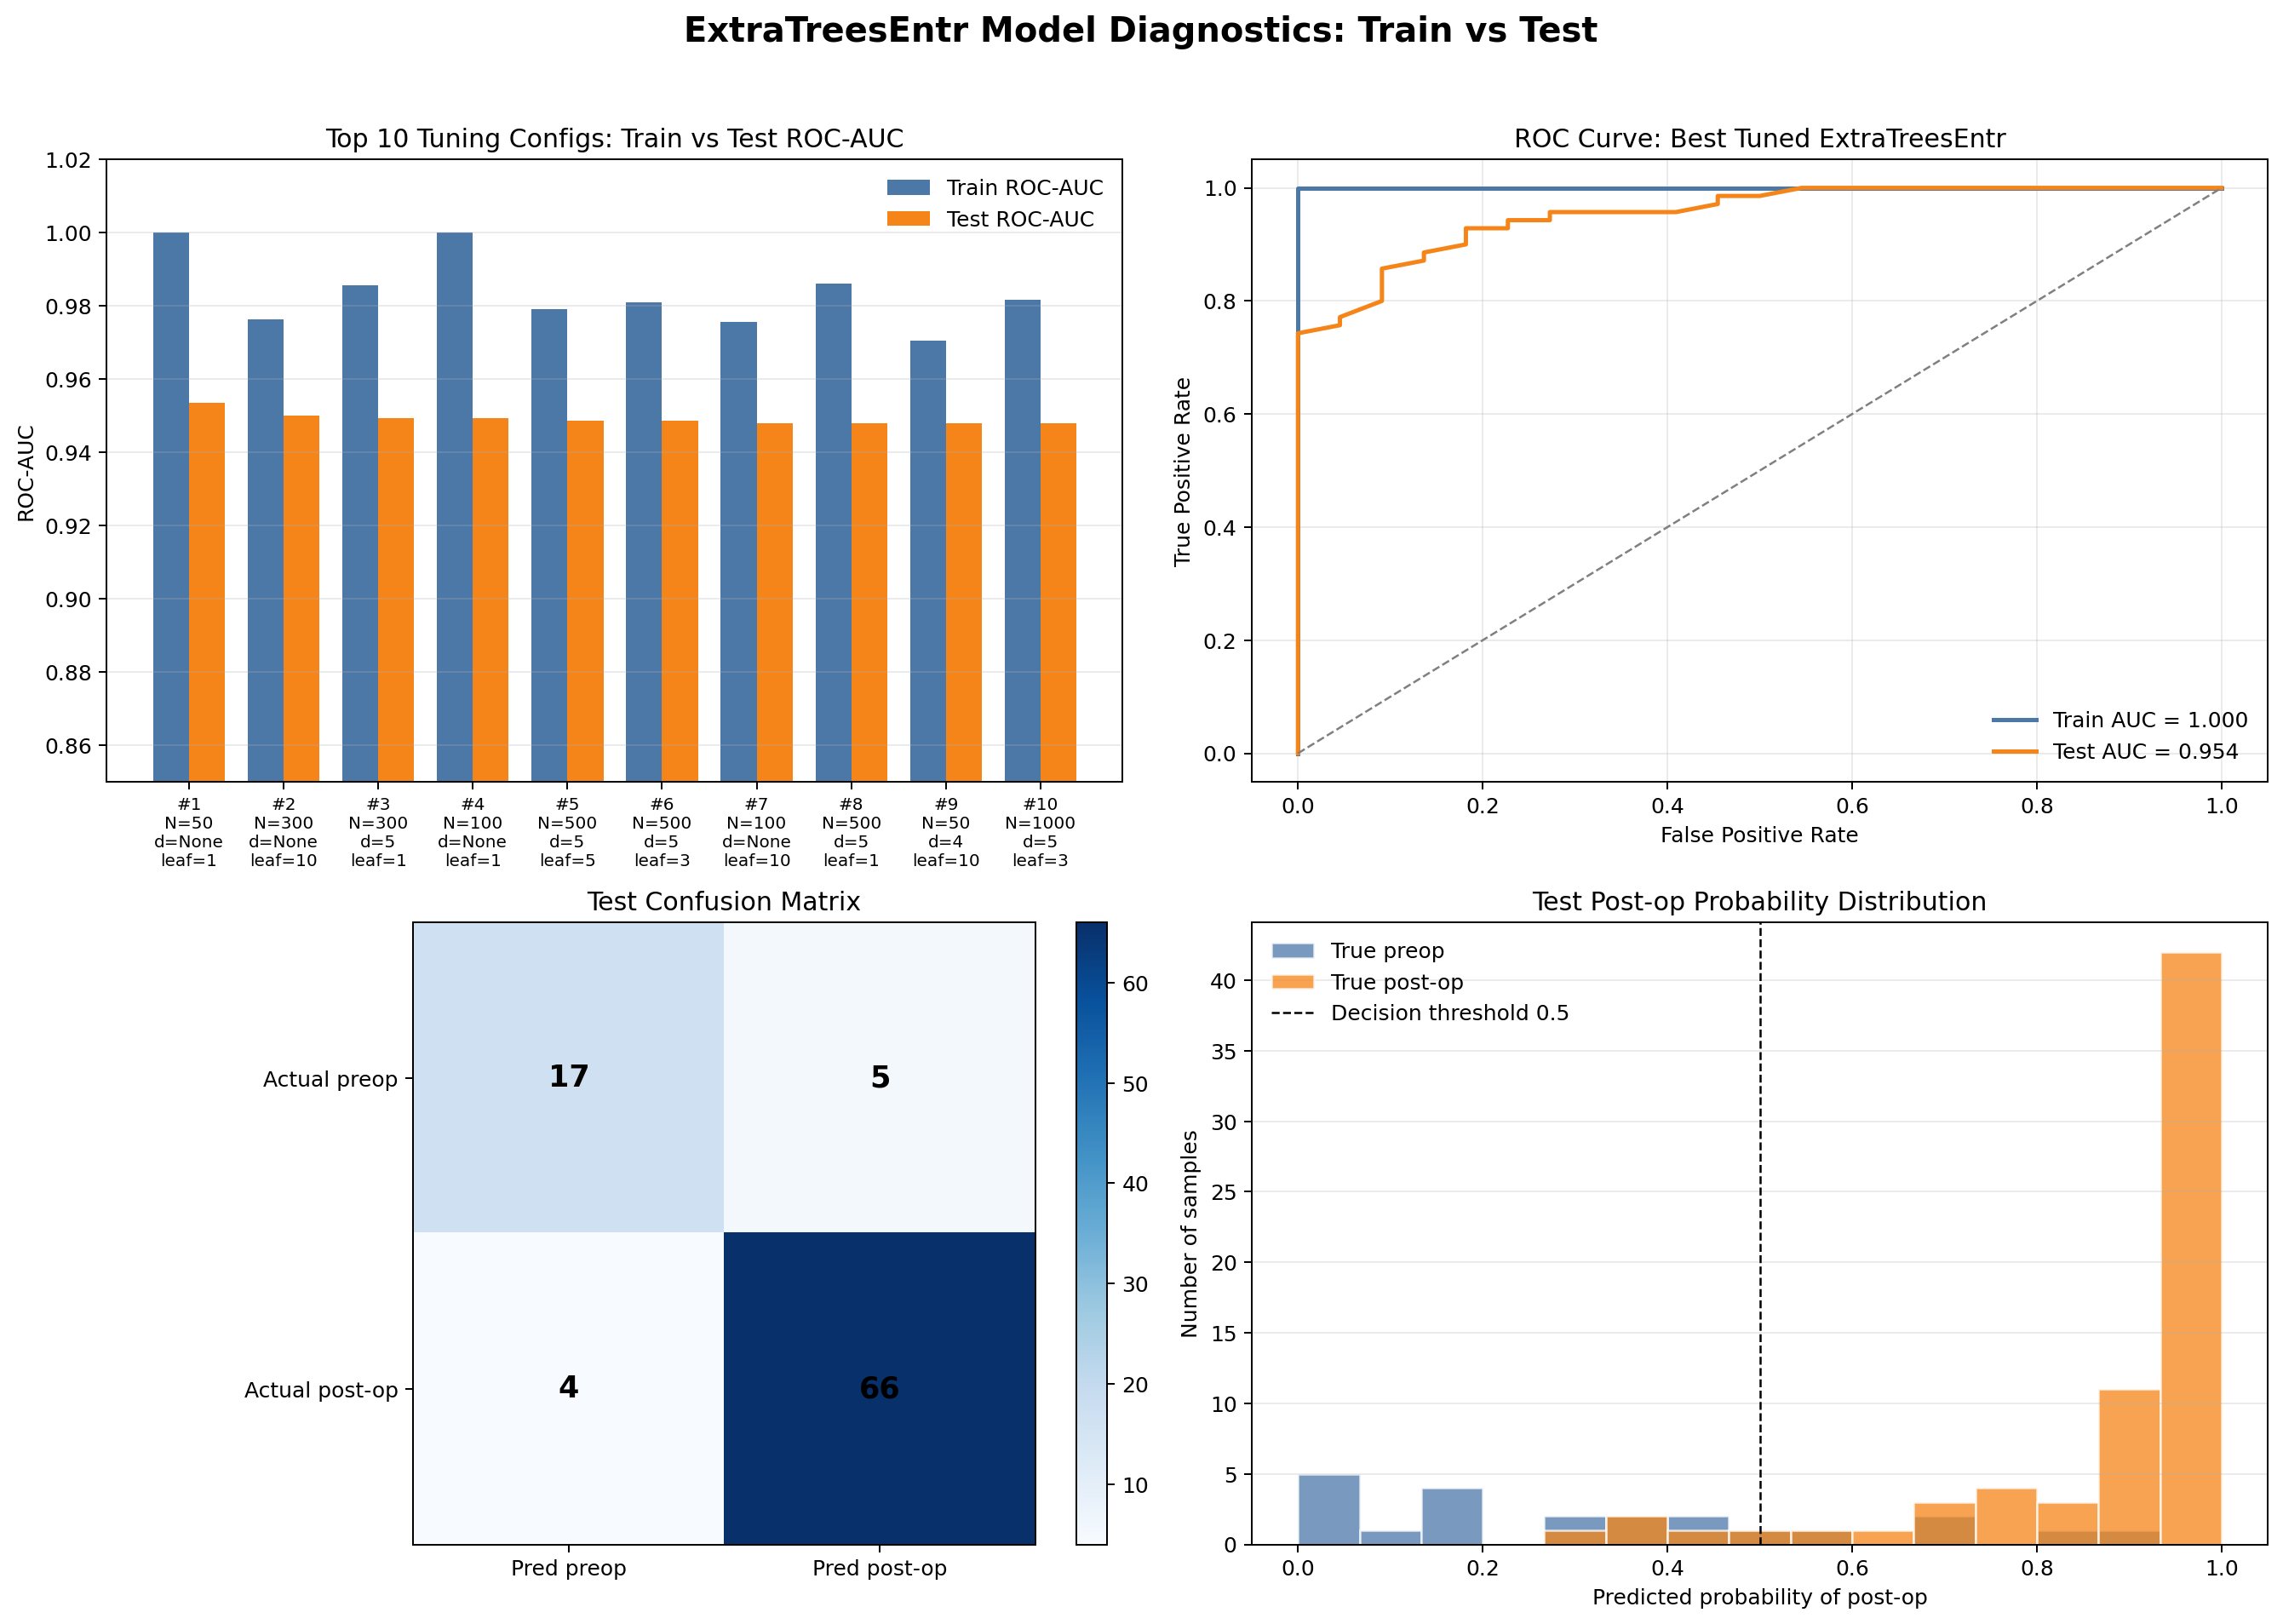

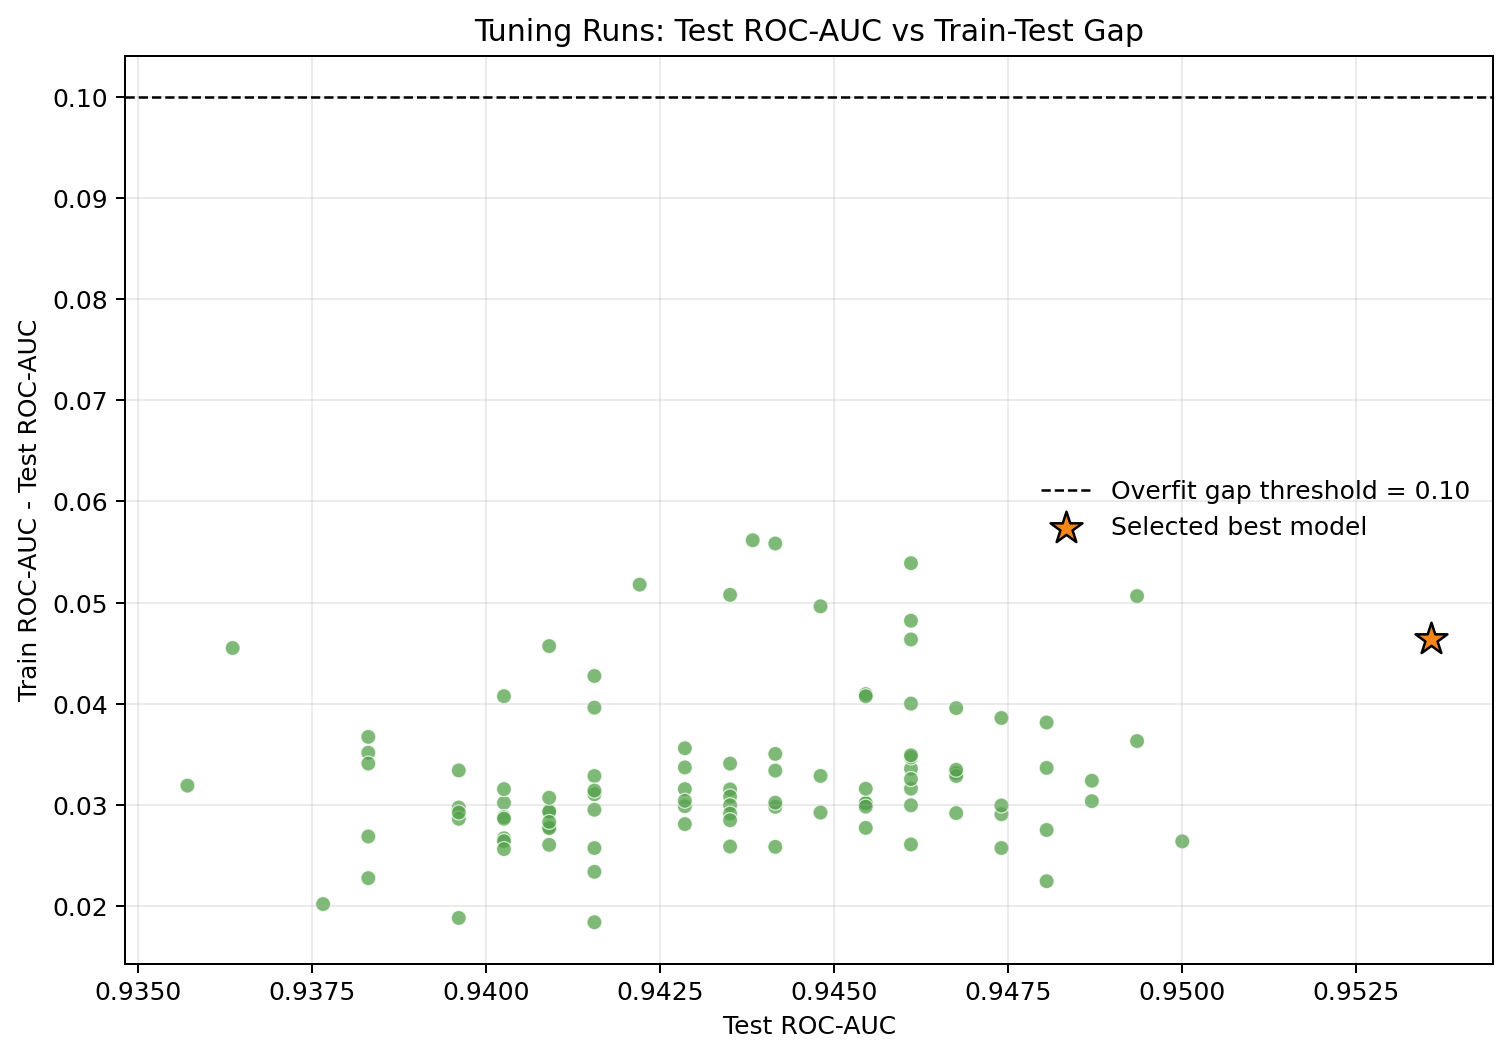

In [26]:

# Step 10: Plot train vs test diagnostics for the tuned ExtraTreesEntr model

import os
os.environ.setdefault('MPLCONFIGDIR', str((DATA_DIR / '.matplotlib_cache').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(exist_ok=True)

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

PLOT_DIR = MODELING_DIR / 'model_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
DIAGNOSTIC_PLOT_PATH = PLOT_DIR / 'extratreesentr_train_test_diagnostics.png'
TUNING_GAP_PLOT_PATH = PLOT_DIR / 'extratreesentr_tuning_auc_gap.png'
PLOT_SUMMARY_PATH = PLOT_DIR / 'plot_summary.json'

train_proba = best_model.predict_proba(X_train)[:, 1]
test_proba = best_model.predict_proba(X_test)[:, 1]
train_auc = roc_auc_score(y_train, train_proba)
test_auc = roc_auc_score(y_test, test_proba)
fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)

top10 = results.head(10).copy()
top10['config_label'] = [f"#{i+1}\nN={int(row.n_estimators)}\nd={row.max_depth}\nleaf={int(row.min_samples_leaf)}" for i, row in enumerate(top10.itertuples())]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('ExtraTreesEntr Model Diagnostics: Train vs Test', fontsize=16, fontweight='bold')

ax = axes[0, 0]
x = np.arange(len(top10))
bar_w = 0.38
ax.bar(x - bar_w / 2, top10['train_roc_auc'], width=bar_w, label='Train ROC-AUC', color='#4C78A8')
ax.bar(x + bar_w / 2, top10['test_roc_auc'], width=bar_w, label='Test ROC-AUC', color='#F58518')
ax.set_ylim(0.85, 1.02)
ax.set_title('Top 10 Tuning Configs: Train vs Test ROC-AUC')
ax.set_ylabel('ROC-AUC')
ax.set_xticks(x)
ax.set_xticklabels(top10['config_label'], fontsize=8)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)

ax = axes[0, 1]
ax.plot(fpr_train, tpr_train, label=f'Train AUC = {train_auc:.3f}', color='#4C78A8', linewidth=2)
ax.plot(fpr_test, tpr_test, label=f'Test AUC = {test_auc:.3f}', color='#F58518', linewidth=2)
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_title('ROC Curve: Best Tuned ExtraTreesEntr')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(frameon=False, loc='lower right')
ax.grid(alpha=0.25)

ax = axes[1, 0]
im = ax.imshow(cm.values, cmap='Blues')
ax.set_title('Test Confusion Matrix')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred preop', 'Pred post-op'])
ax.set_yticklabels(['Actual preop', 'Actual post-op'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm.values[i, j]), ha='center', va='center', color='black', fontsize=14, fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1, 1]
bins = np.linspace(0, 1, 16)
ax.hist(test_proba[y_test.values == 0], bins=bins, alpha=0.75, label='True preop', color='#4C78A8', edgecolor='white')
ax.hist(test_proba[y_test.values == 1], bins=bins, alpha=0.75, label='True post-op', color='#F58518', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision threshold 0.5')
ax.set_title('Test Post-op Probability Distribution')
ax.set_xlabel('Predicted probability of post-op')
ax.set_ylabel('Number of samples')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
fig.savefig(DIAGNOSTIC_PLOT_PATH, dpi=180, bbox_inches='tight')
plt.close(fig)

fig2, ax = plt.subplots(figsize=(8.5, 6))
colors = np.where(results['overfit_flag_auc_gap_gt_0_10'], '#E45756', '#54A24B')
ax.scatter(results['test_roc_auc'], results['auc_gap_train_minus_test'], c=colors, alpha=0.75, edgecolor='white', linewidth=0.5)
ax.axhline(OVERFIT_GAP_THRESHOLD, color='black', linestyle='--', linewidth=1, label='Overfit gap threshold = 0.10')
ax.scatter([test_auc], [train_auc - test_auc], s=180, color='#F58518', edgecolor='black', marker='*', label='Selected best model')
ax.set_title('Tuning Runs: Test ROC-AUC vs Train-Test Gap')
ax.set_xlabel('Test ROC-AUC')
ax.set_ylabel('Train ROC-AUC - Test ROC-AUC')
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
fig2.savefig(TUNING_GAP_PLOT_PATH, dpi=180, bbox_inches='tight')
plt.close(fig2)

PLOT_SUMMARY_PATH.write_text(json.dumps({'train_roc_auc': float(train_auc), 'test_roc_auc': float(test_auc), 'auc_gap_train_minus_test': float(train_auc - test_auc)}, ensure_ascii=False, indent=2))

print(f'Saved diagnostic plot: {DIAGNOSTIC_PLOT_PATH}')
print(f'Saved tuning gap plot: {TUNING_GAP_PLOT_PATH}')
if Image is not None:
    display(Image(filename=str(DIAGNOSTIC_PLOT_PATH)))
    display(Image(filename=str(TUNING_GAP_PLOT_PATH)))


## 20.1 Top-6 Biomarker Importance + Preop/Post-op Comparison

กราฟนี้ใช้สำหรับ presentation เพื่ออธิบายว่าทำไมเลือก top-6 metabolites: ด้านซ้ายคือ importance จาก ExtraTrees และด้านขวาคือทิศทางการเปลี่ยนแปลงของ median standardized log1p abundance ระหว่าง `preop` กับ `post-op`. สีเขียวหมายถึงสูงขึ้นหลังผ่า และสีน้ำเงินหมายถึงลดลงหลังผ่า.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

MODELING_DIR = Path('modeling_outputs')
EDA_DIR = Path('eda_outputs')
PLOT_DIR = MODELING_DIR / 'model_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

importance = pd.read_csv(MODELING_DIR / 'extratreesentr_top6' / 'feature_importance.csv')
summary = pd.read_csv(MODELING_DIR / 'feature_selection_top6_summary.csv')
df_log_for_plot = pd.read_csv(EDA_DIR / 'mtbls242_log1p_sample_by_metabolite.csv')

selected = ['Dimethyl sulfone', 'L-valine', 'isopropanol', 'lipoproteins', 'glycine', 'L-leucine']
axis_labels = {
    'post-op metabolic change signal': 'post-op\nchange signal',
    'BCAA / protein metabolism': 'BCAA / insulin\nresistance',
    'ketone/alcohol metabolism or metabolic stress': 'ketone/alcohol\nmetabolic stress',
    'lipid metabolism / cardiometabolic risk': 'lipid metabolism\ncardiometabolic risk',
    'amino-acid metabolism / metabolic health direction': 'metabolic health\ninsulin sensitivity',
}
colors = {'increase': '#2fbf8f', 'decrease': '#3f8fd2'}

plot_df = importance.merge(summary[['metabolite', 'postop_pattern', 'metabolic_axis']], on='metabolite', how='left')
plot_df = plot_df[plot_df['metabolite'].isin(selected)].copy()
plot_df['axis_label'] = plot_df['metabolic_axis'].map(axis_labels).fillna(plot_df['metabolic_axis'])
plot_df['color'] = plot_df['postop_pattern'].map(colors).fillna('#8093a7')
plot_df = plot_df.sort_values('importance', ascending=False).reset_index(drop=True)

# Standardize log1p abundance per metabolite across all samples so the top-6 can be compared on one scale.
X_for_compare = df_log_for_plot[selected].apply(pd.to_numeric, errors='coerce')
X_z_for_compare = (X_for_compare - X_for_compare.mean()) / X_for_compare.std(ddof=0)
z_compare = X_z_for_compare.copy()
z_compare['time_state'] = np.where(df_log_for_plot['time_point'].eq('preop'), 'Preop', 'Post-op')
prepost = z_compare.groupby('time_state')[selected].median().T.rename(columns={'Preop': 'preop_z', 'Post-op': 'postop_z'})

raw_compare = df_log_for_plot.copy()
raw_compare['time_state'] = np.where(raw_compare['time_point'].eq('preop'), 'Preop', 'Post-op')
raw_medians = raw_compare.groupby('time_state')[selected].median().T.rename(columns={'Preop': 'preop_log1p_median', 'Post-op': 'postop_log1p_median'})

plot_df = plot_df.merge(prepost, left_on='metabolite', right_index=True, how='left')
plot_df = plot_df.merge(raw_medians, left_on='metabolite', right_index=True, how='left')
plot_df['delta_z'] = plot_df['postop_z'] - plot_df['preop_z']

fig, (ax_imp, ax_cmp) = plt.subplots(
    1, 2,
    figsize=(15, 6.8),
    gridspec_kw={'width_ratios': [1.08, 1.0], 'wspace': 0.14},
    sharey=True,
)
fig.patch.set_facecolor('#ffffff')
for ax in (ax_imp, ax_cmp):
    ax.set_facecolor('#ffffff')

y = np.arange(len(plot_df))
ax_imp.barh(y, plot_df['importance'], color=plot_df['color'], edgecolor='white', linewidth=1.2, height=0.66)
max_imp = plot_df['importance'].max()
for yi, row in plot_df.iterrows():
    ax_imp.text(row['importance'] + max_imp * 0.035, yi, f"{row['importance']:.3f}", va='center', ha='left', fontsize=10.5, color='#0f2437', fontweight='bold')
    ax_imp.text(max_imp * 1.34, yi, row['axis_label'], va='center', ha='left', fontsize=9.6, color='#334155', linespacing=1.1)
ax_imp.text(max_imp * 1.34, -0.62, 'Biological meaning', ha='left', va='center', fontsize=10, fontweight='bold', color='#0f2437')
ax_imp.set_xlim(0, max_imp * 2.02)
ax_imp.set_yticks(y)
ax_imp.set_yticklabels(plot_df['metabolite'], fontsize=11, color='#0f2437')
ax_imp.invert_yaxis()
ax_imp.set_xlabel('ExtraTrees importance', fontsize=10.8, color='#334155')
ax_imp.set_title('1. Why these metabolites?', loc='left', fontsize=13, fontweight='bold', color='#0f2437', pad=10)
ax_imp.grid(axis='x', color='#e2edf4', linewidth=1, alpha=0.95)

for yi, row in plot_df.iterrows():
    color = row['color']
    ax_cmp.plot([row['preop_z'], row['postop_z']], [yi, yi], color=color, linewidth=3, alpha=0.78, solid_capstyle='round')
    ax_cmp.scatter(row['preop_z'], yi, s=95, color='#ffffff', edgecolor='#64748b', linewidth=2.0, zorder=3)
    ax_cmp.scatter(row['postop_z'], yi, s=110, color=color, edgecolor='white', linewidth=1.4, zorder=4)
    ha = 'left' if row['delta_z'] >= 0 else 'right'
    text_x = row['postop_z'] + (0.07 if row['delta_z'] >= 0 else -0.07)
    sign = '+' if row['delta_z'] >= 0 else ''
    ax_cmp.text(text_x, yi, f"{sign}{row['delta_z']:.2f} z", va='center', ha=ha, fontsize=10.2, color='#0f2437', fontweight='bold')
ax_cmp.axvline(0, color='#94a3b8', linewidth=1.1, linestyle='--')
ax_cmp.set_xlabel('Median standardized log1p abundance (z-score)', fontsize=10.8, color='#334155')
ax_cmp.set_title('2. Preop vs post-op direction', loc='left', fontsize=13, fontweight='bold', color='#0f2437', pad=10)
ax_cmp.grid(axis='x', color='#e2edf4', linewidth=1, alpha=0.95)
ax_cmp.set_xlim(float(np.nanmin(plot_df[['preop_z', 'postop_z']].values)) - 0.35, float(np.nanmax(plot_df[['preop_z', 'postop_z']].values)) + 0.35)

for ax in (ax_imp, ax_cmp):
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#cbd8e3')
    ax.tick_params(axis='x', colors='#475569')
ax_cmp.tick_params(axis='y', length=0, labelleft=False)

legend_handles = [
    Patch(facecolor=colors['increase'], label='Higher after surgery'),
    Patch(facecolor=colors['decrease'], label='Lower after surgery'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='white', markeredgecolor='#64748b', markeredgewidth=2, markersize=8, label='Preop median'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#0f2437', markeredgecolor='white', markersize=8, label='Post-op median'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.015), fontsize=10)
fig.suptitle('Top-6 Biomarker Importance with Preop vs Post-op Comparison', fontsize=18, fontweight='bold', color='#0f2437', y=0.98)
fig.text(0.06, 0.915, 'Importance comes from ExtraTrees. Preop/post-op comparison uses median z-score after log1p normalization.', fontsize=10.5, color='#64748b')
plt.subplots_adjust(top=0.86, bottom=0.15, left=0.16, right=0.98)

output_png = PLOT_DIR / 'top6_importance_preop_postop_comparison.png'
output_svg = PLOT_DIR / 'top6_importance_preop_postop_comparison.svg'
output_csv = PLOT_DIR / 'top6_importance_preop_postop_comparison.csv'
fig.savefig(output_png, dpi=240, bbox_inches='tight')
fig.savefig(output_svg, bbox_inches='tight')
plot_df[['metabolite', 'importance', 'postop_pattern', 'axis_label', 'preop_z', 'postop_z', 'delta_z', 'preop_log1p_median', 'postop_log1p_median']].to_csv(output_csv, index=False)
plt.show()

print(f'Saved plot: {output_png}')
print(f'Saved table: {output_csv}')
display(plot_df[['metabolite', 'importance', 'postop_pattern', 'preop_z', 'postop_z', 'delta_z']].round(3))


## 21. How to Read Model Diagnostic Plots

ใช้กราฟดู train/test gap, ROC curve, confusion matrix และ probability distribution ของ model output


## 22. Optional: Single-Feature Training Check

Train ทีละ metabolite เพื่อดูว่าสารเดี่ยวตัวไหนมี signal และ overfit แค่ไหน


In [27]:

# Optional: train one-feature-at-a-time ExtraTreesEntr models

SINGLE_FEATURE_DIR = MODELING_DIR / 'single_feature_extratreesentr'
SINGLE_FEATURE_DIR.mkdir(parents=True, exist_ok=True)
SINGLE_FEATURE_METRICS_PATH = SINGLE_FEATURE_DIR / 'one_feature_metrics.csv'

single_rows = []
for feature in selected_features:
    model = ExtraTreesClassifier(n_estimators=500, criterion='entropy', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train[[feature]], y_train)
    one_train_proba = model.predict_proba(X_train[[feature]])[:, 1]
    one_test_proba = model.predict_proba(X_test[[feature]])[:, 1]
    one_test_pred = model.predict(X_test[[feature]])
    train_auc_one = roc_auc_score(y_train, one_train_proba)
    test_auc_one = roc_auc_score(y_test, one_test_proba)
    single_rows.append({
        'metabolite': feature,
        'train_roc_auc': float(train_auc_one),
        'test_roc_auc': float(test_auc_one),
        'auc_gap_train_minus_test': float(train_auc_one - test_auc_one),
        'test_accuracy': float(accuracy_score(y_test, one_test_pred)),
        'test_balanced_accuracy': float(balanced_accuracy_score(y_test, one_test_pred)),
        'test_f1': float(f1_score(y_test, one_test_pred, zero_division=0)),
        'overfit_flag_auc_gap_gt_0_10': bool((train_auc_one - test_auc_one) > OVERFIT_GAP_THRESHOLD),
    })

single_feature_metrics = pd.DataFrame(single_rows).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
single_feature_metrics.insert(0, 'rank_by_test_auc', np.arange(1, len(single_feature_metrics) + 1))
single_feature_metrics.to_csv(SINGLE_FEATURE_METRICS_PATH, index=False)

display(single_feature_metrics)
print(f'Saved single-feature metrics: {SINGLE_FEATURE_METRICS_PATH}')


,rank_by_test_auc,metabolite,train_roc_auc,test_roc_auc,auc_gap_train_minus_test,test_accuracy,test_balanced_accuracy,test_f1,overfit_flag_auc_gap_gt_0_10
0,1,L-valine,1.0,0.801948,0.198052,0.826087,0.714286,0.890411,True
1,2,Dimethyl sulfone,1.0,0.775649,0.224351,0.804348,0.715584,0.873239,True
2,3,L-leucine,1.0,0.736364,0.263636,0.771739,0.662987,0.853147,True
3,4,isopropanol,1.0,0.735390,0.264610,0.717391,0.611688,0.814286,True
4,5,lipoproteins,1.0,0.705519,0.294481,0.684783,0.605844,0.785185,True
5,6,glycine,1.0,0.592532,0.407468,0.717391,0.564935,0.821918,True


Saved single-feature metrics: modeling_outputs/single_feature_extratreesentr/one_feature_metrics.csv


## 23. Model Architecture Diagram

Cell นี้สร้างภาพ architecture ของ modeling pipeline ตั้งแต่ clean EDA data ไปจนถึง final ExtraTreesEntr model และ evaluation metrics


In [ ]:

# Step 11: Generate model architecture diagram

from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', str((Path('.') / '.matplotlib_cache').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(exist_ok=True)

import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

MODEL_PLOT_DIR = Path('modeling_outputs') / 'model_plots'
MODEL_PLOT_DIR.mkdir(parents=True, exist_ok=True)
ARCH_PATH = MODEL_PLOT_DIR / 'model_architecture_pipeline.png'
ARCH_SUMMARY_PATH = MODEL_PLOT_DIR / 'model_architecture_summary.json'

train_top6 = pd.read_csv(Path('modeling_outputs') / 'train_scaled_selected_top6.csv')
test_top6 = pd.read_csv(Path('modeling_outputs') / 'test_scaled_selected_top6.csv')
tuning = pd.read_csv(Path('modeling_outputs') / 'extratreesentr_complexity_tuning' / 'tuning_results.csv')
confusion = pd.read_csv(Path('modeling_outputs') / 'extratreesentr_complexity_tuning' / 'best_model_confusion_matrix.csv', index_col=0)
features = json.loads((Path('modeling_outputs') / 'selected_top6_metabolite_features.json').read_text())['selected_top6_metabolite_features']

best = tuning.iloc[0]
metrics = {
    'test_roc_auc': float(best['test_roc_auc']),
    'test_accuracy': float(best['test_accuracy']),
    'test_f1': float(best['test_f1']),
    'auc_gap_train_minus_test': float(best['auc_gap_train_minus_test']),
}
params = {
    'n_estimators': int(best['n_estimators']),
    'max_depth': None if pd.isna(best['max_depth']) else int(best['max_depth']),
    'min_samples_leaf': int(best['min_samples_leaf']),
    'criterion': 'entropy',
}

fig, ax = plt.subplots(figsize=(17, 10))
ax.set_xlim(0, 17)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#F8FAFC')

COLORS = {
    'input': '#DBEAFE',
    'prep': '#DCFCE7',
    'feature': '#FEF3C7',
    'model': '#EDE9FE',
    'eval': '#FCE7F3',
    'output': '#E0F2FE',
    'line': '#334155',
}

def box(x, y, w, h, title, body, color, fontsize=10):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.03,rounding_size=0.12',
        linewidth=1.4,
        edgecolor='#334155',
        facecolor=color,
    )
    ax.add_patch(patch)
    ax.text(x + 0.18, y + h - 0.28, title, fontsize=12, fontweight='bold', va='top', color='#0F172A')
    ax.text(x + 0.18, y + h - 0.72, body, fontsize=fontsize, va='top', color='#1E293B', linespacing=1.3)
    return patch

def arrow(x1, y1, x2, y2):
    arr = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='-|>', mutation_scale=18,
        linewidth=1.8,
        color=COLORS['line'],
        shrinkA=4, shrinkB=4,
    )
    ax.add_patch(arr)

ax.text(8.5, 9.65, 'NMR Metabolomics Model Architecture', ha='center', va='center', fontsize=22, fontweight='bold', color='#0F172A')
ax.text(8.5, 9.25, 'Goal: classify metabolic state as preop vs post-op from selected NMR metabolites', ha='center', va='center', fontsize=12, color='#475569')

box(0.6, 6.9, 3.1, 1.8, '1. Input', 'Clean EDA table\n465 samples\n21 metabolites\nlog1p abundance', COLORS['input'])
box(4.4, 6.9, 3.1, 1.8, '2. Label', 'preop = 0\npost-op = 1\nTime points: 3/6/9/12m', COLORS['prep'])
box(8.2, 6.9, 3.5, 1.8, '3. Feature Panel', 'Top-6 metabolites:\n' + '\n'.join(features[:3]) + '\n' + '\n'.join(features[3:]), COLORS['feature'], fontsize=9.2)
box(12.6, 6.9, 3.6, 1.8, '4. Split + Scale', f'Group split by subject_id\nTrain: {len(train_top6)} samples\nTest: {len(test_top6)} samples\nScaler fit on train only', COLORS['prep'])

box(1.0, 3.75, 4.2, 1.9, '5. Model Tuning', 'ExtraTreesEntr equivalent\nGrid: n_estimators, max_depth, min_samples_leaf\nChoose high test AUC + low train-test gap', COLORS['model'], fontsize=10)
box(6.3, 3.75, 4.1, 1.9, '6. Final Model', f'ExtraTreesClassifier\ncriterion = entropy\nn_estimators = {params["n_estimators"]}\nmax_depth = {params["max_depth"]}\nmin_samples_leaf = {params["min_samples_leaf"]}', COLORS['model'])
box(11.5, 3.75, 4.5, 1.9, '7. Evaluation', f'Held-out subject-level test\nROC-AUC = {metrics["test_roc_auc"]:.3f}\nAccuracy = {metrics["test_accuracy"]:.3f}\nF1 = {metrics["test_f1"]:.3f}\nAUC gap = {metrics["auc_gap_train_minus_test"]:.3f}', COLORS['eval'])

box(1.0, 1.0, 4.2, 1.7, '8. Prediction Output', 'For each sample:\n- predicted label\n- post-op probability\n- correct / incorrect flag', COLORS['output'])
box(6.3, 1.0, 4.1, 1.7, '9. Confusion Matrix', f'Actual preop: {int(confusion.loc["actual_preop", "pred_preop"])} correct, {int(confusion.loc["actual_preop", "pred_postop"])} as post-op\nActual post-op: {int(confusion.loc["actual_postop", "pred_postop"])} correct, {int(confusion.loc["actual_postop", "pred_preop"])} as preop', COLORS['eval'])
box(11.5, 1.0, 4.5, 1.7, '10. Interpretation', 'Metabolic-state classifier\nNot a disease diagnosis model\nUseful for recovery monitoring\nand nutrition planning support', COLORS['output'])

arrow(3.7, 7.8, 4.4, 7.8)
arrow(7.5, 7.8, 8.2, 7.8)
arrow(11.7, 7.8, 12.6, 7.8)
arrow(14.4, 6.9, 3.1, 5.65)
arrow(5.2, 4.7, 6.3, 4.7)
arrow(10.4, 4.7, 11.5, 4.7)
arrow(13.75, 3.75, 13.75, 2.7)
arrow(11.5, 1.85, 10.4, 1.85)
arrow(6.3, 1.85, 5.2, 1.85)

# Small note for model reliability
note = 'Reliability check: group split prevents subject leakage; AUC gap < 0.10 suggests limited overfit in this split.'
ax.text(8.5, 0.35, note, ha='center', fontsize=11, color='#475569')

plt.tight_layout()
fig.savefig(ARCH_PATH, dpi=180, bbox_inches='tight')
plt.close(fig)

ARCH_SUMMARY_PATH.write_text(json.dumps({
    'architecture_plot': str(ARCH_PATH),
    'model': 'ExtraTreesClassifier / ExtraTreesEntr equivalent',
    'features': features,
    'train_samples': int(len(train_top6)),
    'test_samples': int(len(test_top6)),
    'params': params,
    'metrics': metrics,
    'confusion_matrix': confusion.to_dict(),
    'interpretation': 'Metabolic-state classifier for preop vs post-op, not disease diagnosis.',
}, ensure_ascii=False, indent=2))

print(f'Saved model architecture diagram: {ARCH_PATH}')
print(f'Saved model architecture summary: {ARCH_SUMMARY_PATH}')
if Image is not None:
    display(Image(filename=str(ARCH_PATH)))


## 24. Rule-Based Recovery Score

เพิ่ม rule-based layer เพื่ออธิบายผลโมเดลและแปลง metabolite pattern เป็น recovery score สำหรับ app โภชนาการ

หลักการ:

- ใช้ **train median** เป็น threshold เพื่อไม่ให้ test leakage
- ถ้า metabolite ไปทาง post-op-like direction จะได้ +1 คะแนน
- score รวม 0-6

Rule direction:

- `L-valine`, `L-leucine`, `lipoproteins`, `isopropanol` ต่ำกว่า train median = +1
- `Dimethyl sulfone`, `glycine` สูงกว่า train median = +1

แปลผล:

- `0-2` = preop-like
- `3` = transition
- `4-6` = post-op-like


In [28]:

# Step 12: Rule-based recovery score using train median thresholds

from pathlib import Path
import json
import numpy as np
import pandas as pd

MODELING_DIR = Path('modeling_outputs')
RULE_DIR = MODELING_DIR / 'rule_based_recovery'
RULE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_TOP6_PATH = MODELING_DIR / 'train_scaled_selected_top6.csv'
TEST_TOP6_PATH = MODELING_DIR / 'test_scaled_selected_top6.csv'
SELECTED_FEATURES_PATH = MODELING_DIR / 'selected_top6_metabolite_features.json'

RULE_THRESHOLDS_PATH = RULE_DIR / 'rule_thresholds_train_median.csv'
TRAIN_RULE_OUTPUT_PATH = RULE_DIR / 'train_rule_based_recovery_scores.csv'
TEST_RULE_OUTPUT_PATH = RULE_DIR / 'test_rule_based_recovery_scores.csv'
RULE_SUMMARY_PATH = RULE_DIR / 'rule_based_recovery_summary.csv'
RULE_METADATA_PATH = RULE_DIR / 'metadata.json'

LABEL_COL = 'label_preop_postop'

train_rule = pd.read_csv(TRAIN_TOP6_PATH)
test_rule = pd.read_csv(TEST_TOP6_PATH)
selected_features_rule = json.loads(SELECTED_FEATURES_PATH.read_text())['selected_top6_metabolite_features']

# Post-op-like rules. Thresholds are calibrated from train set only.
rule_config = {
    'L-valine': {'direction': 'low', 'postop_signal': 'BCAA lower than train median'},
    'L-leucine': {'direction': 'low', 'postop_signal': 'BCAA lower than train median'},
    'lipoproteins': {'direction': 'low', 'postop_signal': 'lipid signal lower than train median'},
    'isopropanol': {'direction': 'low', 'postop_signal': 'metabolic stress marker lower than train median'},
    'Dimethyl sulfone': {'direction': 'high', 'postop_signal': 'post-op signal higher than train median'},
    'glycine': {'direction': 'high', 'postop_signal': 'metabolic health signal higher than train median'},
}

missing_rule_features = [feature for feature in rule_config if feature not in selected_features_rule]
if missing_rule_features:
    raise ValueError(f'Rule features missing from selected features: {missing_rule_features}')

threshold_rows = []
for feature, cfg in rule_config.items():
    threshold_rows.append({
        'metabolite': feature,
        'direction_for_postop_like': cfg['direction'],
        'train_median_threshold_scaled': float(train_rule[feature].median()),
        'rule': ('value < train median' if cfg['direction'] == 'low' else 'value > train median'),
        'postop_signal': cfg['postop_signal'],
    })
thresholds = pd.DataFrame(threshold_rows)
thresholds.to_csv(RULE_THRESHOLDS_PATH, index=False)

threshold_map = thresholds.set_index('metabolite')['train_median_threshold_scaled'].to_dict()

def apply_recovery_rules(df, split_name):
    out = df[['Sample Name', 'subject_id', 'time_point', 'label_name', LABEL_COL] + list(rule_config.keys())].copy()
    out.insert(0, 'split', split_name)
    score_parts = []
    reason_parts = []

    for feature, cfg in rule_config.items():
        threshold = threshold_map[feature]
        if cfg['direction'] == 'low':
            passed = out[feature] < threshold
            reason_text = f'low {feature}'
        else:
            passed = out[feature] > threshold
            reason_text = f'high {feature}'

        score_col = f'rule_{feature}_postop_like'
        out[score_col] = passed.astype(int)
        score_parts.append(score_col)
        reason_parts.append((feature, reason_text, passed))

    out['rule_recovery_score'] = out[score_parts].sum(axis=1)
    out['rule_recovery_state'] = np.select(
        [out['rule_recovery_score'] <= 2, out['rule_recovery_score'] == 3, out['rule_recovery_score'] >= 4],
        ['preop-like', 'transition', 'post-op-like'],
        default='unknown',
    )
    out['rule_binary_label'] = np.select(
        [out['rule_recovery_score'] <= 2, out['rule_recovery_score'] >= 4],
        [0, 1],
        default=np.nan,
    )

    reason_strings = []
    for row_idx in out.index:
        reasons = []
        for feature, reason_text, passed in reason_parts:
            if bool(passed.loc[row_idx]):
                reasons.append(reason_text)
        reason_strings.append('; '.join(reasons) if reasons else 'no post-op-like rule matched')
    out['rule_reasons'] = reason_strings

    out['nutrition_followup_flag'] = np.select(
        [
            out['rule_recovery_state'] == 'preop-like',
            out['rule_recovery_state'] == 'transition',
            out['rule_recovery_state'] == 'post-op-like',
        ],
        [
            'closer dietitian follow-up',
            'monitor recovery / review nutrition adherence',
            'routine follow-up / maintain plan',
        ],
        default='review manually',
    )
    return out

train_rule_scores = apply_recovery_rules(train_rule, 'train')
test_rule_scores = apply_recovery_rules(test_rule, 'test')

train_rule_scores.to_csv(TRAIN_RULE_OUTPUT_PATH, index=False)
test_rule_scores.to_csv(TEST_RULE_OUTPUT_PATH, index=False)

summary_rows = []
for split_name, scored in [('train', train_rule_scores), ('test', test_rule_scores)]:
    confident = scored['rule_binary_label'].notna()
    summary_rows.append({
        'split': split_name,
        'n_samples': int(len(scored)),
        'preop_like_n': int((scored['rule_recovery_state'] == 'preop-like').sum()),
        'transition_n': int((scored['rule_recovery_state'] == 'transition').sum()),
        'postop_like_n': int((scored['rule_recovery_state'] == 'post-op-like').sum()),
        'confident_coverage_pct': float(confident.mean() * 100),
        'rule_accuracy_confident_only': float((scored.loc[confident, 'rule_binary_label'].astype(int) == scored.loc[confident, LABEL_COL]).mean()) if confident.any() else np.nan,
        'rule_accuracy_if_transition_excluded_n': int(confident.sum()),
    })
rule_summary = pd.DataFrame(summary_rows)
rule_summary.to_csv(RULE_SUMMARY_PATH, index=False)

RULE_METADATA_PATH.write_text(json.dumps({
    'purpose': 'Interpretable rule-based recovery score calibrated with train medians.',
    'threshold_source': 'train_scaled_selected_top6.csv medians only',
    'score_range': '0-6',
    'state_mapping': {'0-2': 'preop-like', '3': 'transition', '4-6': 'post-op-like'},
    'rule_config': rule_config,
    'output_files': {
        'thresholds': str(RULE_THRESHOLDS_PATH),
        'train_scores': str(TRAIN_RULE_OUTPUT_PATH),
        'test_scores': str(TEST_RULE_OUTPUT_PATH),
        'summary': str(RULE_SUMMARY_PATH),
    },
}, ensure_ascii=False, indent=2))

print(f'Saved rule thresholds: {RULE_THRESHOLDS_PATH}')
print(f'Saved test rule scores: {TEST_RULE_OUTPUT_PATH}')
print(f'Saved rule summary: {RULE_SUMMARY_PATH}')
display(thresholds)
display(rule_summary)
display(test_rule_scores[['Sample Name', 'time_point', 'label_name', 'rule_recovery_score', 'rule_recovery_state', 'rule_reasons', 'nutrition_followup_flag']].head(10))


Saved rule thresholds: modeling_outputs/rule_based_recovery/rule_thresholds_train_median.csv
Saved test rule scores: modeling_outputs/rule_based_recovery/test_rule_based_recovery_scores.csv
Saved rule summary: modeling_outputs/rule_based_recovery/rule_based_recovery_summary.csv


,metabolite,direction_for_postop_like,train_median_threshold_scaled,rule,postop_signal
0,L-valine,low,-0.067824,value < train median,BCAA lower than train median
1,L-leucine,low,0.072505,value < train median,BCAA lower than train median
2,lipoproteins,low,-0.105704,value < train median,lipid signal lower than train median
3,isopropanol,low,-0.081355,value < train median,metabolic stress marker lower than train median
4,Dimethyl sulfone,high,-0.052054,value > train median,post-op signal higher than train median
5,glycine,high,0.046316,value > train median,metabolic health signal higher than train median


,split,n_samples,preop_like_n,transition_n,postop_like_n,confident_coverage_pct,rule_accuracy_confident_only,rule_accuracy_if_transition_excluded_n
0,train,373,135,85,153,77.211796,0.791667,288
1,test,92,39,13,40,85.869565,0.784810,79


,Sample Name,time_point,label_name,rule_recovery_score,rule_recovery_state,rule_reasons,nutrition_followup_flag
0,0_0001_S,preop,preop,0,preop-like,no post-op-like rule matched,closer dietitian follow-up
1,0_0008_S,preop,preop,1,preop-like,low isopropanol,closer dietitian follow-up
2,0_0027_S,preop,preop,1,preop-like,high Dimethyl sulfone,closer dietitian follow-up
3,0_0029_S,preop,preop,1,preop-like,high glycine,closer dietitian follow-up
4,0_0030_S,preop,preop,1,preop-like,high glycine,closer dietitian follow-up
5,0_0046_S,preop,preop,1,preop-like,high glycine,closer dietitian follow-up
6,0_0092_S,preop,preop,0,preop-like,no post-op-like rule matched,closer dietitian follow-up
7,0_0110_S,preop,preop,0,preop-like,no post-op-like rule matched,closer dietitian follow-up
8,0_0134_S,preop,preop,1,preop-like,high glycine,closer dietitian follow-up
9,0_0144_S,preop,preop,1,preop-like,high glycine,closer dietitian follow-up


## 25. Combined Output for App: ML Probability + Rule-Based Recovery Score

Cell นี้รวมผลจาก ML model และ rule-based score เป็นไฟล์เดียวสำหรับ app prototype

Output ที่ได้:

- ML predicted label
- ML post-op probability
- rule-based recovery score
- recovery state
- metabolite reasons
- nutrition follow-up flag


In [29]:

# Step 13: Combine ML prediction output with rule-based recovery score for app prototype

from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', str((Path('.') / '.matplotlib_cache').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(exist_ok=True)

import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

MODELING_DIR = Path('modeling_outputs')
RULE_DIR = MODELING_DIR / 'rule_based_recovery'
PLOT_DIR = MODELING_DIR / 'model_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

ML_PREDICTIONS_PATH = MODELING_DIR / 'extratreesentr_complexity_tuning' / 'best_model_test_predictions.csv'
TEST_RULE_OUTPUT_PATH = RULE_DIR / 'test_rule_based_recovery_scores.csv'
COMBINED_APP_OUTPUT_PATH = RULE_DIR / 'combined_app_output_test.csv'
RULE_PLOT_PATH = PLOT_DIR / 'rule_based_recovery_score_distribution.png'

ml_pred = pd.read_csv(ML_PREDICTIONS_PATH)
rule_test = pd.read_csv(TEST_RULE_OUTPUT_PATH)

rule_cols = [
    'Sample Name',
    'rule_recovery_score',
    'rule_recovery_state',
    'rule_binary_label',
    'rule_reasons',
    'nutrition_followup_flag',
]
combined = ml_pred.merge(rule_test[rule_cols], on='Sample Name', how='left', validate='one_to_one')

combined['ml_rule_agreement'] = combined.apply(
    lambda row: (
        'transition' if row['rule_recovery_state'] == 'transition'
        else ('agree' if int(row['predicted_label']) == int(row['rule_binary_label']) else 'disagree')
    ),
    axis=1,
)

combined.to_csv(COMBINED_APP_OUTPUT_PATH, index=False)

summary = pd.DataFrame({
    'metric': [
        'n_test_samples',
        'ml_accuracy',
        'rule_preop_like_n',
        'rule_transition_n',
        'rule_postop_like_n',
        'ml_rule_agree_n',
        'ml_rule_disagree_n',
        'rule_transition_n_for_agreement',
    ],
    'value': [
        len(combined),
        float(combined['correct_prediction'].mean()),
        int((combined['rule_recovery_state'] == 'preop-like').sum()),
        int((combined['rule_recovery_state'] == 'transition').sum()),
        int((combined['rule_recovery_state'] == 'post-op-like').sum()),
        int((combined['ml_rule_agreement'] == 'agree').sum()),
        int((combined['ml_rule_agreement'] == 'disagree').sum()),
        int((combined['ml_rule_agreement'] == 'transition').sum()),
    ],
})

fig, ax = plt.subplots(figsize=(9, 5.5))
order = ['preop-like', 'transition', 'post-op-like']
colors = {'preop-like': '#4C78A8', 'transition': '#F2C94C', 'post-op-like': '#F58518'}
counts = combined['rule_recovery_state'].value_counts().reindex(order, fill_value=0)
bars = ax.bar(counts.index, counts.values, color=[colors[x] for x in counts.index], edgecolor='white', linewidth=1.2)
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.6, str(int(value)), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Rule-Based Recovery State Distribution on Test Set', fontsize=15, fontweight='bold')
ax.set_xlabel('Rule-based recovery state')
ax.set_ylabel('Number of samples')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
fig.savefig(RULE_PLOT_PATH, dpi=180, bbox_inches='tight')
plt.close(fig)

print(f'Saved combined app output: {COMBINED_APP_OUTPUT_PATH}')
print(f'Saved rule-based recovery plot: {RULE_PLOT_PATH}')
display(summary)
display(combined[['Sample Name', 'time_point', 'label_name', 'predicted_label_name', 'post_op_probability', 'rule_recovery_score', 'rule_recovery_state', 'ml_rule_agreement', 'nutrition_followup_flag']].head(12))


Saved combined app output: modeling_outputs/rule_based_recovery/combined_app_output_test.csv
Saved rule-based recovery plot: modeling_outputs/model_plots/rule_based_recovery_score_distribution.png


,metric,value
0,n_test_samples,92.000000
1,ml_accuracy,0.902174
2,rule_preop_like_n,39.000000
3,rule_transition_n,13.000000
4,rule_postop_like_n,40.000000
5,ml_rule_agree_n,61.000000
6,ml_rule_disagree_n,18.000000
7,rule_transition_n_for_agreement,13.000000


,Sample Name,time_point,label_name,predicted_label_name,post_op_probability,rule_recovery_score,rule_recovery_state,ml_rule_agreement,nutrition_followup_flag
0,0_0001_S,preop,preop,post-op,0.54,0,preop-like,disagree,closer dietitian follow-up
1,0_0008_S,preop,preop,post-op,0.68,1,preop-like,disagree,closer dietitian follow-up
2,0_0027_S,preop,preop,post-op,0.80,1,preop-like,disagree,closer dietitian follow-up
3,0_0029_S,preop,preop,preop,0.18,1,preop-like,agree,closer dietitian follow-up
4,0_0030_S,preop,preop,preop,0.00,1,preop-like,agree,closer dietitian follow-up
5,0_0046_S,preop,preop,preop,0.30,1,preop-like,agree,closer dietitian follow-up
6,0_0092_S,preop,preop,preop,0.06,0,preop-like,agree,closer dietitian follow-up
7,0_0110_S,preop,preop,preop,0.42,0,preop-like,agree,closer dietitian follow-up
8,0_0134_S,preop,preop,preop,0.16,1,preop-like,agree,closer dietitian follow-up
9,0_0144_S,preop,preop,preop,0.00,1,preop-like,agree,closer dietitian follow-up


## ExtraTreesEntr Confusion Matrix

Cell นี้ plot confusion matrix ของ final ExtraTreesEntr model บน held-out subject-level test set

อ่านแกนแบบนี้:

- แถว = actual label จริง
- คอลัมน์ = prediction ของโมเดล
- ค่าแนวทแยง = ทายถูก
- ค่านอกแนวทแยง = ทายผิด



In [ ]:
# Step 13: Plot final ExtraTreesEntr confusion matrix
import matplotlib.pyplot as plt
import numpy as np

CM_PATH = MODELING_OUTPUT_DIR / 'extratreesentr_complexity_tuning' / 'best_model_confusion_matrix.csv'
CONFUSION_MATRIX_PLOT_PATH = PLOT_OUTPUT_DIR / 'extratreesentr_confusion_matrix.png'

cm_df = pd.read_csv(CM_PATH, index_col=0)
cm = cm_df.to_numpy(dtype=int)
actual_labels = ['Preop', 'Post-op']
pred_labels = ['Preop', 'Post-op']

fig, ax = plt.subplots(figsize=(7.2, 6.0), dpi=180)
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())

ax.set_title('Confusion Matrix', fontsize=18, pad=18)
ax.set_ylabel('Actual', fontsize=12, labelpad=10)
ax.set_xlabel('Prediction', fontsize=12, labelpad=10)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

ax.set_xticks(np.arange(len(pred_labels)))
ax.set_yticks(np.arange(len(actual_labels)))
ax.set_xticklabels(pred_labels, fontsize=11)
ax.set_yticklabels(actual_labels, fontsize=11)

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > threshold else '#08306b'
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', color=color, fontsize=15)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8)

ax.set_xticks(np.arange(-0.5, cm.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, cm.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.06)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
fig.savefig(CONFUSION_MATRIX_PLOT_PATH, bbox_inches='tight', facecolor='white')
plt.show()

display(cm_df)
print(f'Saved plot to: {CONFUSION_MATRIX_PLOT_PATH}')


